Camino encontrado: [(0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (1, 4), (2, 4), (3, 4), (4, 4)]
Visitados: {(0, 1), (4, 4), (2, 4), (0, 4), (3, 4), (0, 0), (0, 3), (1, 4), (0, 2)}


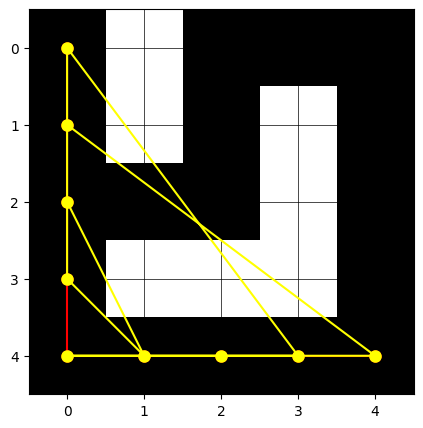

In [17]:
# Búsqueda primero en anchura
import matplotlib.pyplot as plt
import numpy as np
from collections import deque

def bfs_laberinto(laberinto, inicio, destino):
  FILAS, COLUMNAS = len(laberinto), len(laberinto[0])
  cola = deque()
  cola.append((inicio, [inicio]))  # (posición, camino)
  visitados = set()
  visitados.add(inicio)
  while cola:
    (columna, fila), camino = cola.popleft()
    if (columna, fila) == destino:
      return camino, visitados
    MOVIMIENTOS = [
      ( 0,  1), # abajo
      ( 1,  0), # derecha
      ( 0, -1), # arriba
      (-1,  0), # izquierda
    ]
    for dx, dy in MOVIMIENTOS:
      x, y = fila + dx, columna + dy
      if x >= 0 and x < COLUMNAS and y >= 0 and y < FILAS:
        if laberinto[y][x] == 1:
          if (x, y) not in visitados:
            cola.append(((y, x), camino + [(x, y)]))
            visitados.add((x, y))
            break
  return None

def resolver_laberinto(laberinto):
    return bfs_laberinto(laberinto, (0,0), (4,4))

def dibujar_laberinto(laberinto, camino, visitados):
    filas, columnas = len(laberinto), len(laberinto[0])
    laberinto_np = np.array(laberinto)
    plt.figure(figsize=(5,5))
    plt.imshow(laberinto_np, cmap='gray_r')
    if camino:
        x, y = zip(*camino)
        plt.plot(x, y, marker='o', color='red', markersize=8, linestyle='-')
    if visitados:
        x, y = zip(*visitados)
        plt.plot(x, y, marker='o', color='yellow', markersize=8, linestyle='-')
    plt.xticks(range(columnas))
    plt.yticks(range(filas))
    plt.grid(True, which='both', linestyle='-', color='black', linewidth=0.5)
    plt.show()

laberinto = [
    [1, 0, 1, 1, 1],
    [1, 0, 1, 0, 1],
    [1, 1, 1, 0, 1],
    [1, 0, 0, 0, 1],
    [1, 1, 1, 1, 1],
]
camino, visitados = resolver_laberinto(laberinto)
if camino:
  print('Camino encontrado:', camino)
  print('Visitados:', visitados)
  dibujar_laberinto(laberinto, camino, visitados)
else:
  print('No hay camino')
